In [8]:
import os
import subprocess 

from datasets import load_dataset, load_from_disk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots 

plt.style.use("science")

DATA_ROOT = os.getenv("DATA_ROOT")
latex_bin_path = f"{DATA_ROOT}/texlive_store/texlive/bin/x86_64-linux"
os.environ["PATH"] = latex_bin_path + os.pathsep + os.environ["PATH"]

try:
    version = subprocess.check_output(["latex", "--version"]).decode().splitlines()[0]
    print(f"Using LaTeX version: {version}")
except Exception as e:
    print(f"Error finding LaTeX: {e}")

# Now enable LaTeX rendering
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

Using LaTeX version: pdfTeX 3.141592653-2.6-1.40.28 (TeX Live 2025)


In [9]:
from astropy.cosmology.realizations import Planck18
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

cosmo = Planck18

## NYU VAC abs mags

In [10]:
DATA_ROOT = os.getenv("DATA_ROOT")

fp = f"{DATA_ROOT}/sdss/vol_limited_embeddings_7655991_0/z=0.150"
data_files = {
    "test": f"{fp}/test"
}

ds = load_from_disk(
    f"{fp}"
)

In [11]:
cosmo = FlatLambdaCDM(H0=100, Om0=0.3) # Cosmology used in the SDSS sample
# 2. Re-calculate Distance Modulus with h=1
z_grid = np.linspace(0.001, 0.3, 500)
D_L = cosmo.luminosity_distance(z_grid).to(u.pc)
d0 = 10. * u.pc
DM = 5 * np.log10(D_L/d0)

# 4. The limiting curve
m_lim = 17.77
M_lim_curve = m_lim - DM

In [12]:
z_grid = np.linspace(0.001, 0.3, 500)

Plotting 12945 galaxies after cuts.


/tmp/ipykernel_3281930/3216056876.py:89: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="lower right")


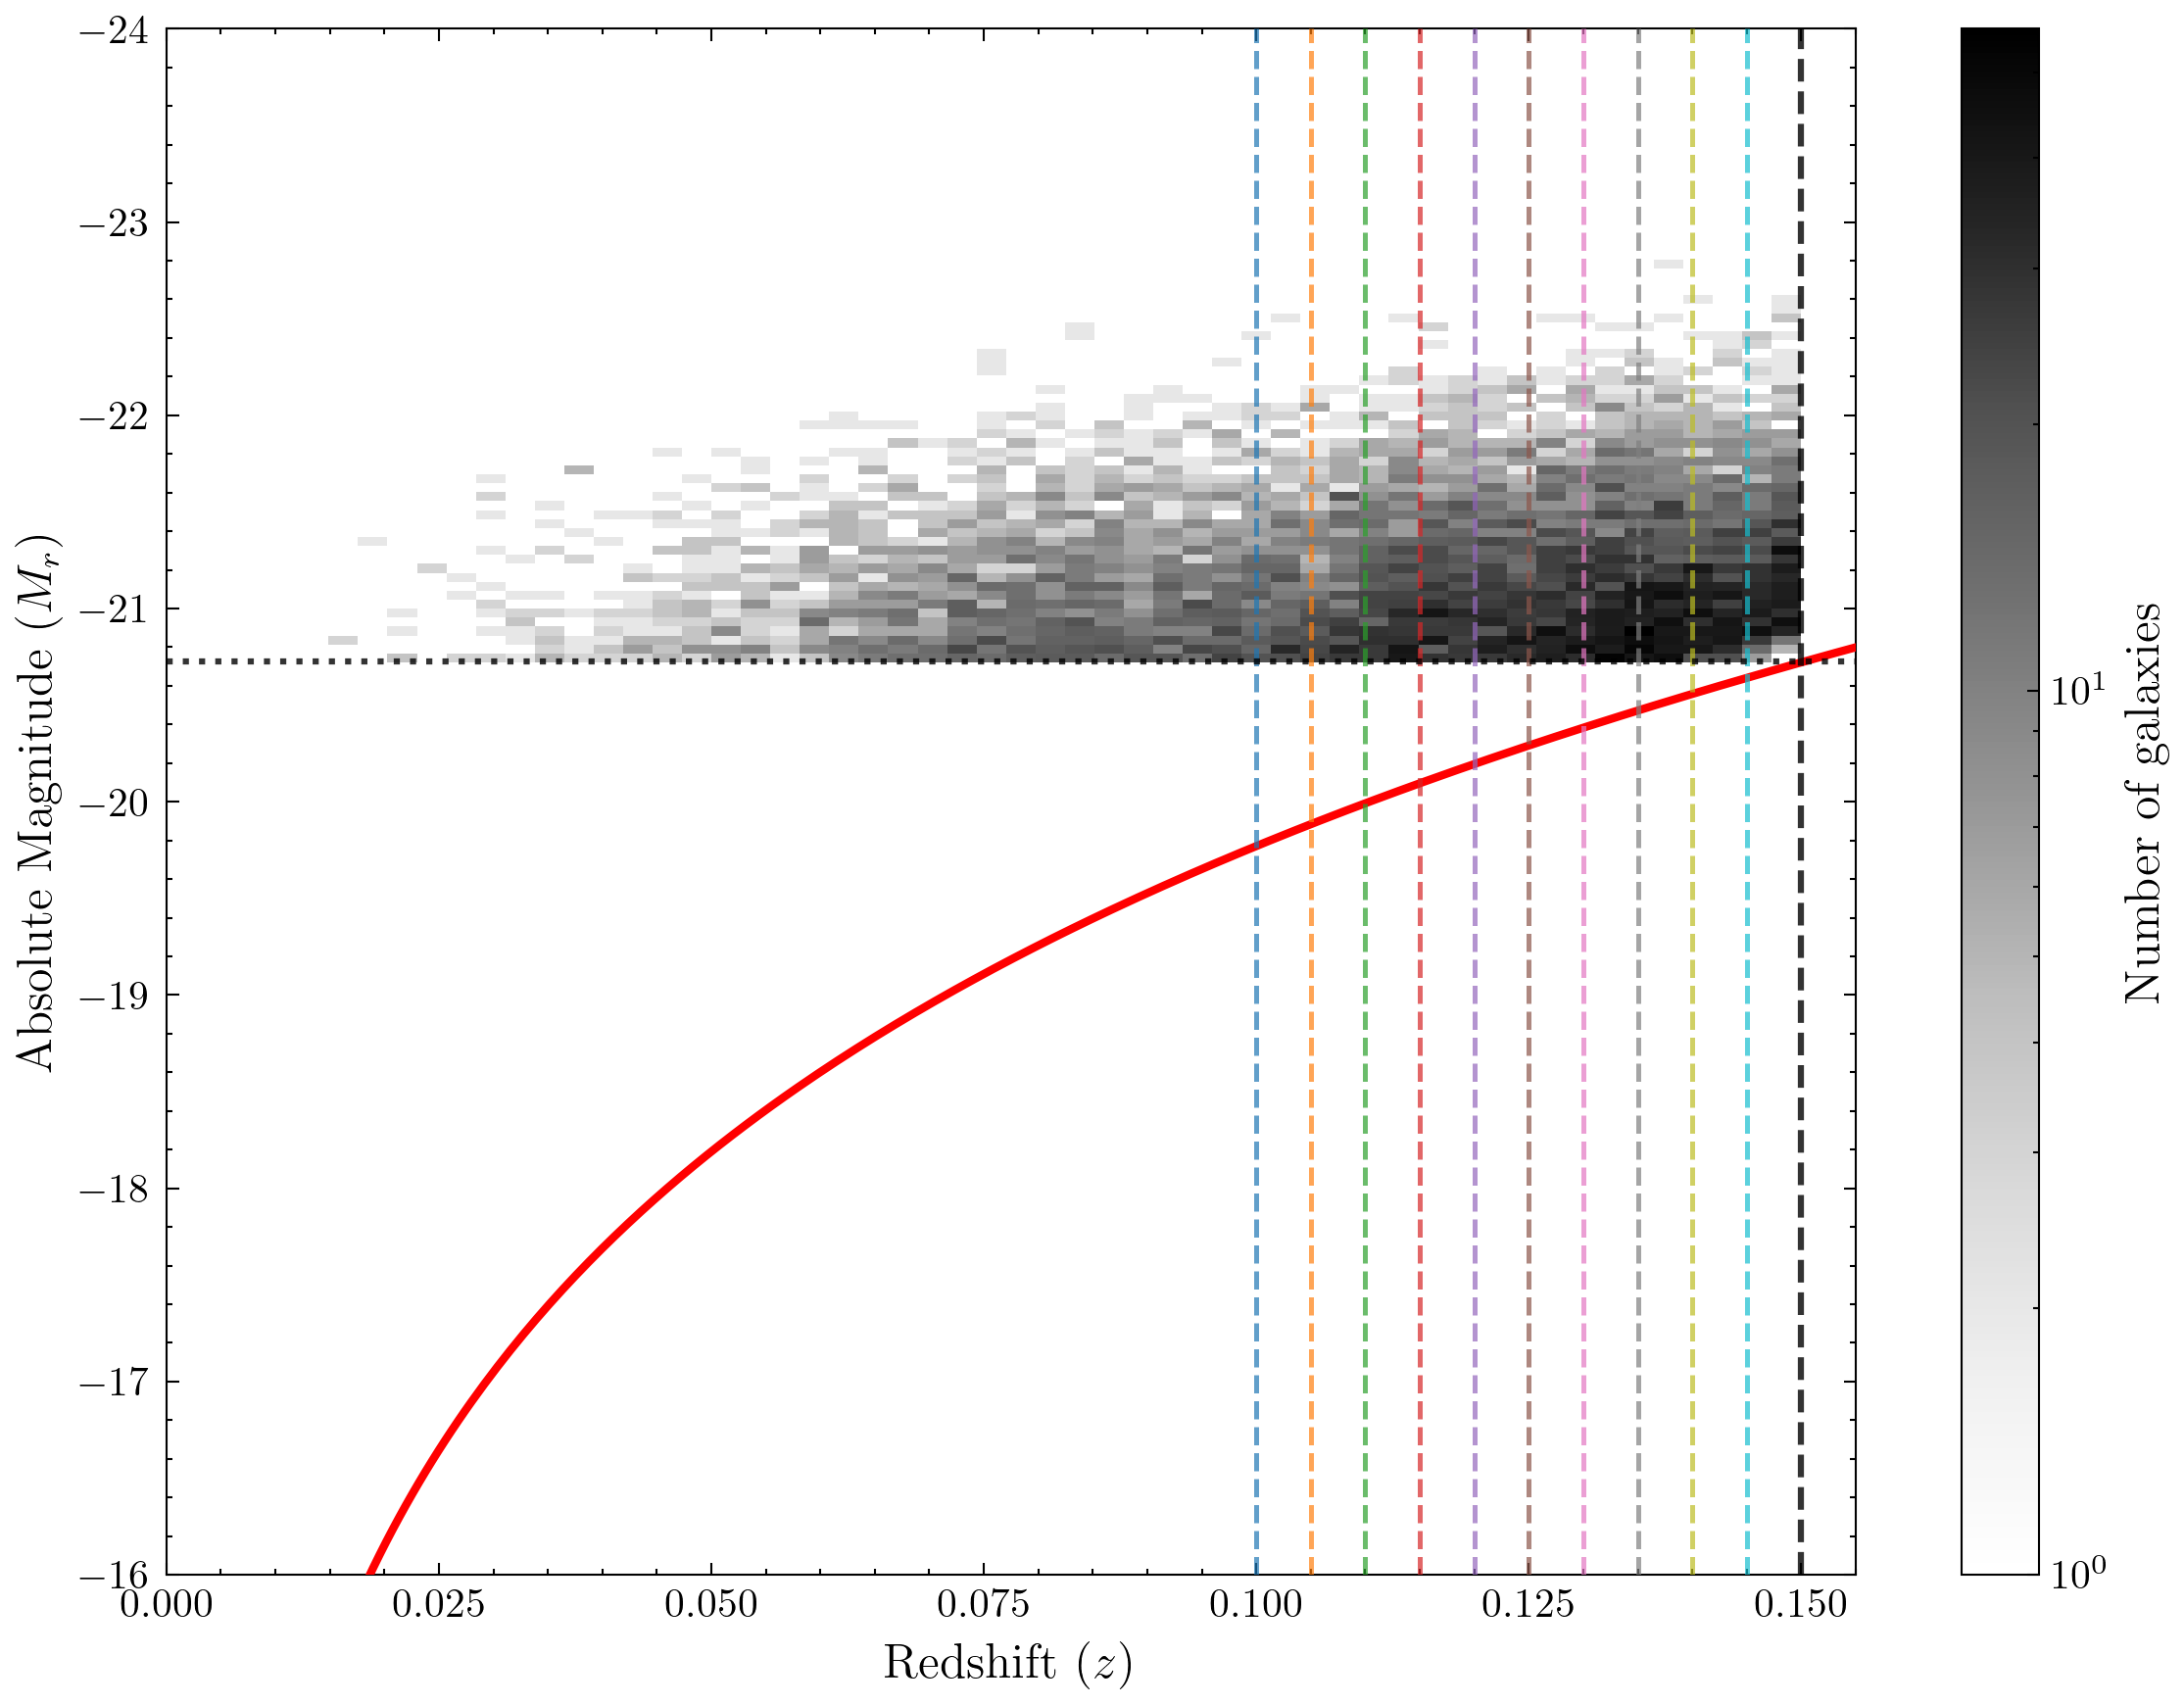

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.colors import LogNorm
# from datasets import load_from_disk

# Assuming z_grid and M_lim_curve are already defined in your environment

DATA_ROOT = os.getenv("DATA_ROOT")

# Load the dataset for z=0.150
base_z_lim = "0.150"
# fp = f"{DATA_ROOT}/sdss/magnitude_limited_embeddings_7655991_0/z={base_z_lim}"
# ds = load_from_disk(fp)

# Create a single plot
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

z_all = np.array(ds["test"]["z"])
abs_mag_all = np.array(ds["test"]["ABSMAG_r"])
mask_ratio_all = np.array(ds["test"]["mask_ratio"])

# Filters for redshift <= 0.150 AND mask_ratio <= 1.0
mask = (z_all <= 0.150) & (mask_ratio_all != 1.0)

# 3. Apply the mask to your plotting variables
z_filtered = z_all[mask]
abs_mag_filtered = abs_mag_all[mask]

# Optional sanity check matching your snippet
print(f"Plotting {len(z_filtered)} galaxies after cuts.")

z_filtered = z_all[mask]
abs_mag_filtered = abs_mag_all[mask]

# --- DENSITY PLOT ---
h = ax.hist2d(
    z_filtered, 
    abs_mag_filtered, 
    bins=50, 
    cmap='Greys',    
    norm=LogNorm(),    
    cmin=1             
)

# Add a colorbar mapped to the 2D histogram
cb = fig.colorbar(h[3], ax=ax)
cb.set_label('Number of galaxies', fontsize=12)

# Calculate limits
idx_0150 = np.argmin(np.abs(z_grid - 0.150))
m_lim_at_0150 = M_lim_curve[idx_0150]

# --- SAMPLE CUT LINES ---
# Generate z values from 0.100 to 0.145 at 0.005 intervals
z_cuts = np.arange(0.100, 0.150, 0.005)

# Get distinct colors for each line using the tab10 colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(z_cuts)))

for z_cut, color in zip(z_cuts, colors):
    ax.axvline(
        x=z_cut, 
        color=color, 
        linestyle='--', 
        linewidth=1.2, 
        alpha=0.7, 
        zorder=6
    )
# ------------------------

# Add the apparent magnitude limit curve
ax.plot(z_grid, M_lim_curve, color='red', linewidth=2, zorder=5)

# Add limit indicators
ax.axvline(x=0.150, color='black', linestyle='--', linewidth=1.5, alpha=0.8, zorder=6)
ax.axhline(y=m_lim_at_0150, color='black', linestyle=':', linewidth=1.5, alpha=0.8, zorder=6)

# Labels and Titles
ax.set_ylabel("Absolute Magnitude ($M_r$)", fontsize=12, fontweight='bold')
ax.set_xlabel("Redshift ($z$)", fontsize=12)

# Set limits to focus on the data
ax.set_ylim(-16, -24)
ax.set_xlim(0.001, 0.155)

plt.xticks([0.0, 0.025, 0.05, 0.075, 0.10, 0.125, 0.15])

ax.legend(loc="lower right")

plt.tight_layout()
plt.show()